# **Time Series Analysis and Prediction**

In [ ]:
!pip install statsmodels
!pip install pmdarima --upgrade

In [ ]:
#imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

## **Application 1: Demand Forecasting (Air Passenger)**

**Data Preprocessing**

In [ ]:
#upload airPassengers.cvs

airpass=pd.read_csv("/content/AirPassengers.csv")
airpass.shape

(144, 2)

In [ ]:
plt.style.use('dark_background')

In [ ]:
#change column name
airpass.rename(columns = {'Month':'Date','#Passengers':'Passengers'}, inplace = True)
#convert date datatype to date
airpass['Date'] = pd.to_datetime(airpass['Date'])

#changing index
airpass.set_index('Date', inplace=True)

airpass.head()

,Passengers
Date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### **Time Series EDA**

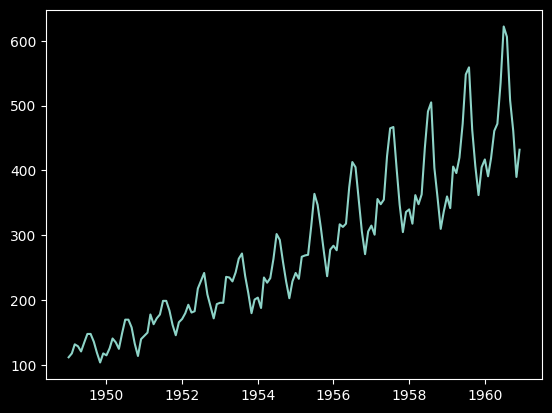

In [ ]:
#plotting passangers over date
plt.plot(airpass['Passengers'])

**Check if Data is stationary?**

In [ ]:
#Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller
adf, pvalue, usedlag_, nobs_, critical_values_, icbest_ = adfuller(airpass)
print("pvalue = ", pvalue, " if above 0.05, data is not stationary")
#Since data is not stationary, we may need SARIMA and not just ARIMA

pvalue =  0.991880243437641  if above 0.05, data is not stationary


**Extract and plot trend, seasonal and residuals.**

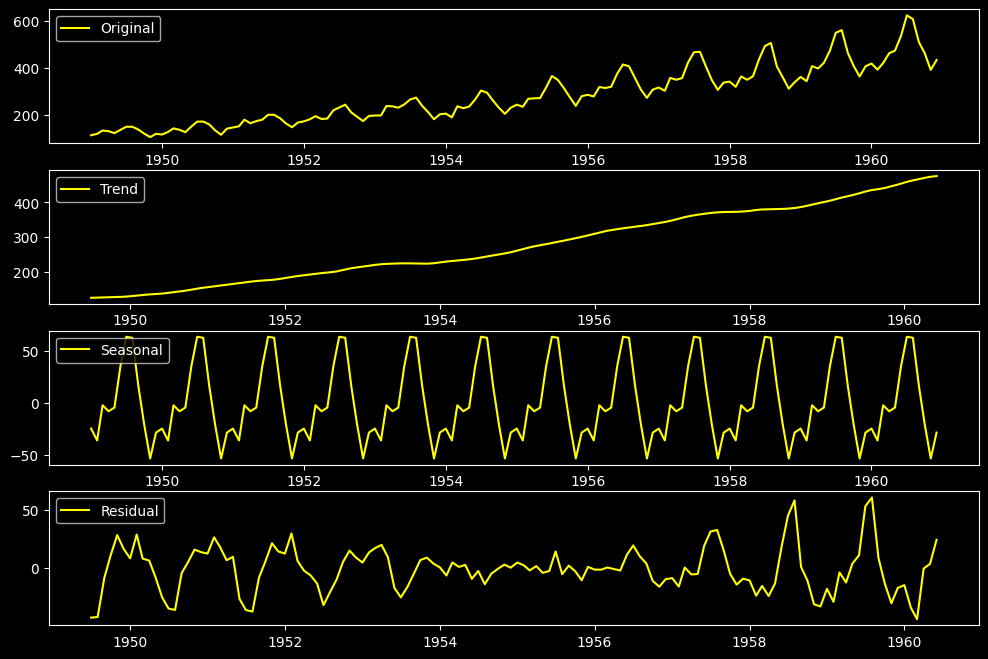

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose


decomposed = seasonal_decompose(airpass['Passengers'],  model ='additive') #try model=Multiplicative

trend = decomposed.trend #there is positive growth trend
seasonal = decomposed.seasonal #the graph shows the cycle is yearly
residual = decomposed.resid #this is error so we should not see a pattern

plt.figure(figsize=(12,8))
plt.subplot(411)
plt.plot(airpass['Passengers'], label='Original', color='yellow')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Trend', color='yellow')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal', color='yellow')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual, label='Residual', color='yellow')
plt.legend(loc='upper left')
plt.show()

**Finding Monthly trends**

In [ ]:
#create a new dataframe years with month as rows
years=pd.DataFrame(index=range(1,13)) #get 12 month as rows
airpass=airpass.reset_index()

#group by columns by year
#create column for each year and destribute the values over months
for name, year_df in airpass.groupby(airpass["Date"].apply(lambda x: x.year)):
  years[name]=year_df["Passengers"].values

years

,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
1,112,115,145,171,196,204,242,284,315,340,360,417
2,118,126,150,180,196,188,233,277,301,318,342,391
3,132,141,178,193,236,235,267,317,356,362,406,419
4,129,135,163,181,235,227,269,313,348,348,396,461
5,121,125,172,183,229,234,270,318,355,363,420,472
6,135,149,178,218,243,264,315,374,422,435,472,535
7,148,170,199,230,264,302,364,413,465,491,548,622
8,148,170,199,242,272,293,347,405,467,505,559,606
9,136,158,184,209,237,259,312,355,404,404,463,508
10,119,133,162,191,211,229,274,306,347,359,407,461


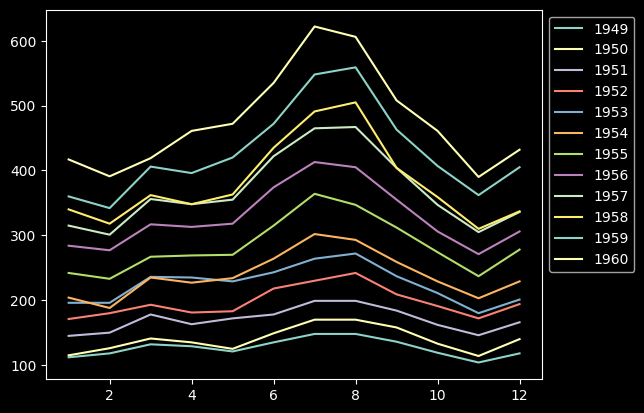

In [ ]:
years.plot().legend(bbox_to_anchor=(1, 1))

**Auto Correlation**<br>
in time series, variable is correlated to itself over a lag. a lag is a period of time (interval) between 2 points of time we like to find  the correlation value for.

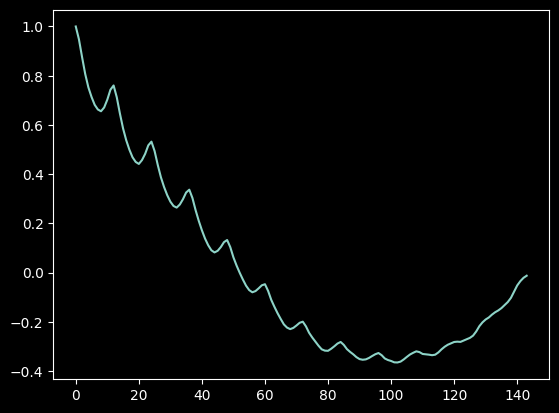

In [ ]:
from statsmodels.tsa.stattools import acf

acf_144 = acf(airpass["Passengers"], nlags=144)
plt.plot(acf_144)

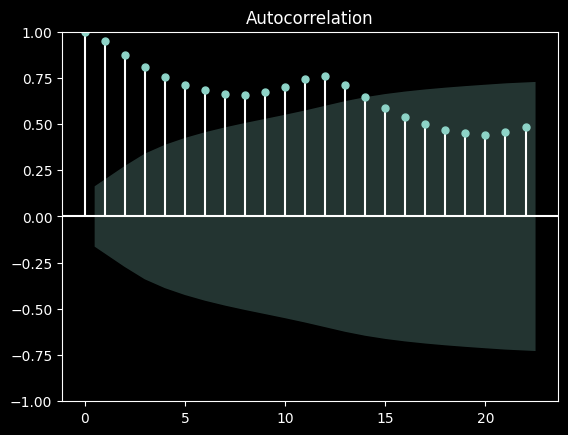

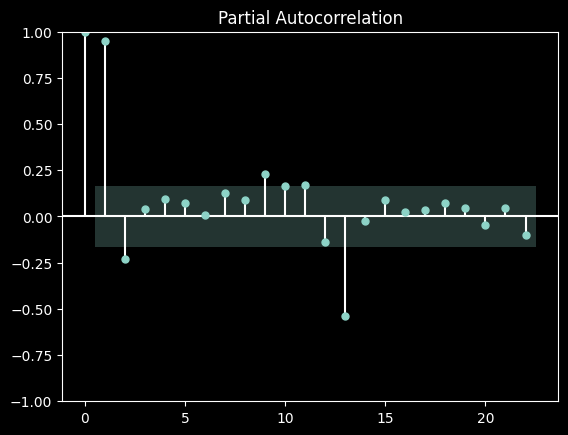

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(airpass["Passengers"])
plot_pacf(airpass["Passengers"]);

In [ ]:
#get autocorrelation based on specific lag
airpass.Passengers.autocorr(12)

0.990527369208544

**Manually creating auto correlation function using pandas shift function**

In [ ]:
from statsmodels.tsa.ar_model import AutoReg


In [ ]:

ac_df=airpass.copy()
#lag here is 3 month ago  which means value at 4th row of original column, becomes value at 1st row of new column
ac_df["shift-3"]=ac_df["Passengers"].shift(-3)

In [ ]:
ac_df["shift12"]=ac_df["Passengers"].shift(12) #check how correlated is data on reayly basis

In [ ]:
ac_df.corr().Passengers

,Passengers
Date,0.923853
Passengers,1.000000
shift-3,0.837395
shift12,0.990527


### **Lagged-Regression**


In [ ]:
from statsmodels.tsa.ar_model import AutoReg
model1=AutoReg(airpass,3)
res=model1.fit()
print(res.summary())

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

# Convert relevant columns to numeric type
# Assuming 'Passengers' is the target variable for the AutoReg model
airpass['Passengers'] = pd.to_numeric(airpass['Passengers'], errors='coerce')

# Drop non-numeric columns
# Select only numeric columns for the model
numeric_columns = airpass.select_dtypes(include=np.number).columns
airpass_numeric = airpass[numeric_columns]

# Build the AutoReg model with the numeric data
model1 = AutoReg(airpass_numeric['Passengers'], lags=3) # Assuming 'Passengers' is the relevant column
res = model1.fit()
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:             Passengers   No. Observations:                  144
Model:                     AutoReg(3)   Log Likelihood                -684.430
Method:               Conditional MLE   S.D. of innovations             31.037
Date:                Tue, 11 Mar 2025   AIC                           1378.860
Time:                        07:08:06   BIC                           1393.603
Sample:                             3   HQIC                          1384.851
                                  144                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            13.6410      6.872      1.985      0.047       0.172      27.110
Passengers.L1     1.3482      0.084     16.025      0.000       1.183       1.513
Passengers.L2    -0.5918      0.136     

**Manually building regression model**

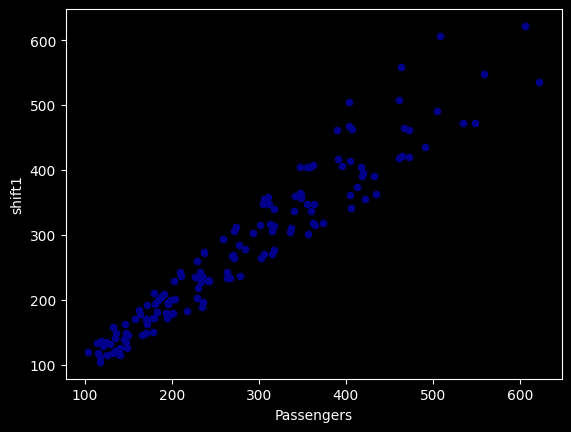

In [ ]:
ar=airpass.copy()
ar["shift1"]=ar["Passengers"].shift(1)
ax1 = ar.plot.scatter(x='Passengers',
                      y='shift1',
                      c='DarkBlue')

In [ ]:
ar["shift2"]=ar["Passengers"].shift(2)
ar["shift3"]=ar["Passengers"].shift(3)

In [ ]:
ar.drop("Passengers", axis=1, inplace=True)

In [ ]:
ar

,Date,shift1,shift2,shift3
0,1949-01-01,NaN,NaN,NaN
1,1949-02-01,112.0,NaN,NaN
2,1949-03-01,118.0,112.0,NaN
3,1949-04-01,132.0,118.0,112.0
4,1949-05-01,129.0,132.0,118.0
...,...,...,...,...
139,1960-08-01,622.0,535.0,472.0
140,1960-09-01,606.0,622.0,535.0
141,1960-10-01,508.0,606.0,622.0
142,1960-11-01,461.0,508.0,606.0


In [ ]:
#convert dataframe into numpy
x=ar.fillna(0).values

In [ ]:
y=airpass.fillna(0).values

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
print(lr.coef_,lr.intercept_)

### **Forecasting using ARIMA/SARIMA/SARIMAX**<br>
ARIMA:Auto-Regressive Integrated Moving Average<br>
SARIMA: Seasonal ARIMA<br>
SARIMAX: SARIMA with Exogenous variables

In [ ]:
#changing index
airpass.set_index('Date', inplace=True)

In [ ]:
from pmdarima.arima import auto_arima
#Auto arima suggests best model and parameters based on
#AIC metric (relative quality of statistical models)
#Autoarima gives us best model suited for the data
# p - number of autoregressive terms (AR)
# q - Number of moving avergae terms (MA)
# d - number of non-seasonal differences
#p, d, q represent non-seasonal components
#P, D, Q represent seasonal components
arima_model = auto_arima(airpass['Passengers'], start_p = 1, d=1, start_q = 1,
                          max_p = 5, max_q = 5, max_d=5, m = 12,
                          start_P = 0, D=1, start_Q=0, max_P=5, max_D=5, max_Q=5,
                          seasonal = True, trace = True,
                          error_action ='ignore',
                          suppress_warnings = True,
                          stepwise = True, n_fits=50)

print(arima_model.summary() ) #check MODEL to see best model for the data

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.25 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.16 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.24 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.08 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.40 sec
 ARIMA(1,1,0)(3,1,0)[12]             : AIC=1020.582, Time=0.89 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=3.62 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.52 sec
 ARIMA(1,1,0)(3,1,1)[12]             : AIC=inf, Time=7.07 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.45 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.57 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.72 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.48 sec
 ARIMA(0,1,1)(1,1,0)[12]     

In [ ]:
#Split data into train and test (take the first 66% as test and the rest as training)
size = int(len(airpass) * 0.66)
X_train, X_test = airpass[0:size], airpass[size:len(airpass)]

In [ ]:
# Fit a SARIMAX(0, 1, 1)x(2, 1, 1, 12) on the training set
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(X_train['Passengers'],
                order = (0, 1, 1),
                seasonal_order =(2, 1, 1, 12))

result = model.fit()
result.summary()

/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         Passengers   No. Observations:                   95
Model:             SARIMAX(0, 1, 1)x(2, 1, 1, 12)   Log Likelihood                -300.269
Date:                            Sun, 05 Mar 2023   AIC                            610.537
Time:                                    11:55:36   BIC                            622.571
Sample:                                01-01-1949   HQIC                           615.368
                                     - 11-01-1956                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3201      0.103     -3.103      0.002      -0.522      -0.118
ar.S.L12       0.6847      0.609      1.124      0.261      -0.509       1.878
ar.S.L24       0.3142      0.125      2.520      0.012       0.070       0.559
ma.S.L12      -0.9812      5.431     -0.181      0.857     -11.626       9.664
sigma2        78.6460    379.218      0.207      0.836    -664.607     821.899
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.56
Prob(Q):                              0.95   Prob(JB):                         0.28
Heteroskedasticity (H):               1.69   Skew:                             0.42
Prob(H) (two-sided):                  0.18   Kurtosis:                         2.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
#Train prediction
start_index = 0
end_index = len(X_train)-1
train_prediction = result.predict(start_index, end_index)

In [ ]:
#TEST Prediction
start_index = len(X_train)
end_index = len(airpass)-1
prediction = result.predict(start_index, end_index).rename('Predicted passengers')

<AxesSubplot:xlabel='Date'>

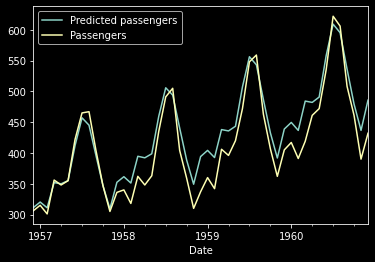

In [ ]:
# plot predictions and actual values
prediction.plot(legend = True)  #prediction
X_test['Passengers'].plot(legend = True) #actual data

In [ ]:
#forecasting
forecast = result.predict(start = len(airpass),
                          end = (len(airpass)-1) + 3 * 12,  # forecast for the next 3 years
                          typ = 'levels').rename('Forecast')

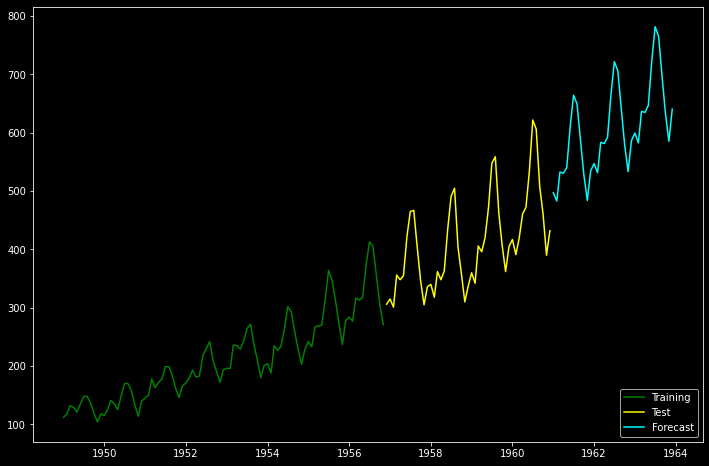

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(X_train, label='Training', color='green')
plt.plot(X_test, label='Test', color='yellow')
plt.plot(forecast, label='Forecast', color='cyan')
plt.legend(loc='lower right')
plt.show();

### **Forecasting using LSTM**

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM, Flatten
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [ ]:
#drop the date column
airpass_=airpass.copy()
airpass_.reset_index(inplace=True)
airpass_.drop("Date", axis=1, inplace=True)

In [ ]:
#scaling the data between minimum and maximum passanger number
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(airpass_)

In [ ]:
#Split data into train and test (take the first 66% as test and the rest as training)
size = int(len(dataset) * 0.66)
train, test = dataset[0:size], dataset[size:len(airpass)]

In [ ]:
#greate a sequence of n+1 (n=feature=number of months to look back, n+1 is the lable)
#seq_size=n
def to_sequences(dataset, seq_size=5):
    x = []
    y = []
    last_index_for_sequence=len(dataset)-seq_size-1
    for i in range(last_index_for_sequence):
        window = dataset[i:(i+seq_size), 0]
        x.append(window) #creating feature set array
        y.append(dataset[i+seq_size, 0]) #creating lable array

    return np.array(x),np.array(y)

In [ ]:
seq_size = 12
trainX, trainY = to_sequences(train, seq_size)
testX, testY = to_sequences(test, seq_size)
print("Shape of training set: {}".format(trainX.shape))
print("Shape of test set: {}".format(testX.shape))

Shape of training set: (82, 12)
Shape of test set: (36, 12)


In [ ]:
# Reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [ ]:
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(None, seq_size)))
model.add(LSTM(50, activation='relu'))
model.add(Dense(32))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, None, 50)          12600     
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dense (Dense)               (None, 32)                1632      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 34,465
Trainable params: 34,465
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.fit(trainX, trainY, validation_data=(testX, testY),
          verbose=2, epochs=100)
# make predictions
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

Epoch 1/100
3/3 - 7s - loss: 0.0665 - val_loss: 0.3623 - 7s/epoch - 2s/step
Epoch 2/100
3/3 - 0s - loss: 0.0541 - val_loss: 0.3225 - 86ms/epoch - 29ms/step
Epoch 3/100
3/3 - 0s - loss: 0.0428 - val_loss: 0.2834 - 92ms/epoch - 31ms/step
Epoch 4/100
3/3 - 0s - loss: 0.0331 - val_loss: 0.2446 - 108ms/epoch - 36ms/step
Epoch 5/100
3/3 - 0s - loss: 0.0256 - val_loss: 0.2059 - 67ms/epoch - 22ms/step
Epoch 6/100
3/3 - 0s - loss: 0.0197 - val_loss: 0.1691 - 75ms/epoch - 25ms/step
Epoch 7/100
3/3 - 0s - loss: 0.0157 - val_loss: 0.1354 - 89ms/epoch - 30ms/step
Epoch 8/100
3/3 - 0s - loss: 0.0131 - val_loss: 0.1077 - 94ms/epoch - 31ms/step
Epoch 9/100
3/3 - 0s - loss: 0.0132 - val_loss: 0.0853 - 100ms/epoch - 33ms/step
Epoch 10/100
3/3 - 0s - loss: 0.0137 - val_loss: 0.0717 - 86ms/epoch - 29ms/step
Epoch 11/100
3/3 - 0s - loss: 0.0140 - val_loss: 0.0653 - 73ms/epoch - 24ms/step
Epoch 12/100
3/3 - 0s - loss: 0.0137 - val_loss: 0.0646 - 72ms/epoch - 24ms/step
Epoch 13/100
3/3 - 0s - loss: 0.0128 - 

In [ ]:
#since we scaled the data, now we need to convert the scaled data back to actual data
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])

testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])


In [ ]:
# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))

testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 13.57 RMSE
Test Score: 74.77 RMSE


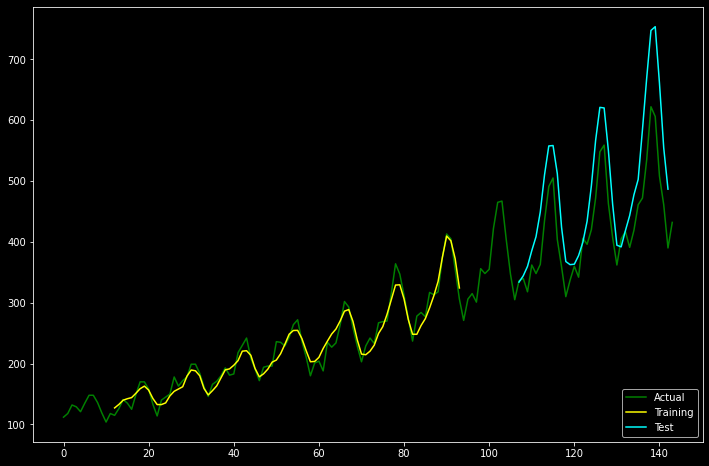

In [ ]:
# shift train predictions for plotting
#we must shift the predictions so that they align on the x-axis with the original dataset.
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[seq_size:len(trainPredict)+seq_size, :] = trainPredict

# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(seq_size*2)+1:len(dataset)-1, :] = testPredict

# plot baseline and predictions
plt.figure(figsize=(12,8))
plt.plot(scaler.inverse_transform(dataset),  label='Actual', color='green')
plt.plot(trainPredictPlot, label='Training', color='yellow')
plt.plot(testPredictPlot, label='Test', color='cyan')
plt.legend(loc='lower right')
plt.show()

